In [16]:
import mdtraj as md
import numpy as np

from tqdm import tqdm
from glob import glob

from pathlib import Path

from matplotlib import pyplot as plt
from matplotlib.ticker import FuncFormatter

In [2]:
def sci_notation_no_sigfigs(number, pos):
    a, b = f"{number:.0e}".split("e")
    b = int(b)
    if b == 0:
        return "0"
    return f"${a} \, \mathrm{{x}} \, 10^{{{b}}}$"


def sci_notation_one_sigfig(number, pos):
    a, b = f"{number:.1e}".split("e")
    b = int(b)
    if b == 0:
        return "0"
    return f"${a} \, \mathrm{{x}} \, 10^{{{b}}}$"

## Load MD and Crystal data

In [3]:
ATOM_SELECTION = '(element != H) and is_protein and (resi < 303) and (resi > 1)'

def load_pdbs(glob_pattern):
    
    crystals = None
    crystal_chis = []

    first = True
    files_to_load = sorted(glob(glob_pattern))
    
    for pdb in tqdm(files_to_load):

        try:
            
            trj = md.load_pdb(pdb)
            idx = trj.top.select(ATOM_SELECTION)
            trj = trj.atom_slice(idx)

            chi_atoms, chi = md.compute_chi1(trj)
            crystal_chis.extend(chi)

            if first:
                chi_idx = [ trj.topology.atom(int(a)).residue.index for a in chi_atoms[:,0] ]
                first = False

            idx = trj.top.select('name == CA')
            trj = trj.atom_slice(idx)

            if crystals:
                crystals = crystals.join(trj, check_topology=False)
            else:
                crystals = trj

        except Exception as exptn:
            print(trj.xyz.shape)
            print(crystals.xyz.shape)
            print("something went wrong", pdb, exptn)

    crystals = crystals.center_coordinates()
    crystal_chis = np.array(crystal_chis)
    
    return crystals, crystal_chis

In [4]:
SUBSAMPLE     = 10 # for MD simulation, 1 = 1 ns

In [5]:
crystals, crystal_chis = load_pdbs('../../allostery/selected_dataset_archive_2024-08-07/pdb/*.pdb')

100%|██████████| 1146/1146 [04:39<00:00,  4.11it/s]


In [6]:
# each dcd file is 1000 frames with 1ns spacing between frames

prefix = '/asap3/petra3/gpfs/p11/2020/data/11009999/shared/mdsim/DESRES-Trajectory_sarscov2-10880334-no-water-no-ion-glueCA'
md_files = sorted(glob(prefix + '/sarscov2-10880334-no-water-no-ion-glueCA/*.dcd'))

top_path = prefix + '/system_nowat.pdb'

md_sim = None
md_chis = []

for f in tqdm(md_files):

    t = md.load(f, top=top_path)[::SUBSAMPLE]

    idx = t.top.select(ATOM_SELECTION)
    t   = t.atom_slice(idx)
    
    _, chis = md.compute_chi1(t)
    md_chis.extend(chis)

    idx = t.top.select('name == CA')
    t   = t.atom_slice(idx)

    if md_sim == None:
        md_sim = t
    else:
        md_sim += t

md_sim = md_sim.center_coordinates()
md_chis = np.array(md_chis)

100%|██████████| 100/100 [00:59<00:00,  1.68it/s]


In [7]:
prefix = '/asap3/petra3/gpfs/p11/2020/data/11009999/shared/diamond_05-May-2020/'
diamond, diamond_chis = load_pdbs(prefix + '*.pdb')

 57%|█████▋    | 60/105 [00:11<00:08,  5.11it/s]

(1, 299, 3)
(59, 301, 3)
something went wrong /asap3/petra3/gpfs/p11/2020/data/11009999/shared/diamond_05-May-2020/Mpro-x1187_0.pdb Number of atoms in self (301) is not equal to number of atoms in other


100%|██████████| 105/105 [00:20<00:00,  5.12it/s]


In [8]:
# phenix ensembles

phenix_ensembles = []
ensemble_pdb_paths = glob('/gpfs/cfel/user/tjlane/mpro/allostery/ensemble_refinements/four_datasets/*/*.updated_ensemble.nowater.pdb')

for ensemble_pdb_path in ensemble_pdb_paths:
    ensemble, _ = load_pdbs(ensemble_pdb_path)
    phenix_ensembles.append(ensemble)

100%|██████████| 1/1 [00:05<00:00,  5.20s/it]


In [9]:
vagabond_pdb_path = '/asap3/petra3/gpfs/p11/2020/data/11009999/shared/ensemble/ensemble_69_superimposed.pdb'
vagabond, vagabond_chis = load_pdbs(vagabond_pdb_path)

100%|██████████| 1/1 [00:08<00:00,  8.11s/it]


In [10]:
print(crystals.xyz.shape, crystal_chis.shape)
print(md_sim.xyz.shape,   md_chis.shape)
print(diamond.xyz.shape,  diamond_chis.shape)
print([ensemble.xyz.shape for ensemble in phenix_ensembles])
print(vagabond.xyz.shape, vagabond_chis.shape)

(1146, 301, 3) (1146, 259)
(10000, 301, 3) (10000, 259)
(104, 301, 3) (105,)
[(67, 301, 3), (29, 301, 3), (50, 301, 3), (50, 301, 3)]
(131, 301, 3) (131, 259)


In [11]:
active_site_residues = np.array([41, 49, 143, 144, 145, 163, 164, 165, 166, 167, 187, 188, 189, 190, 191, 192]) - 3

residues = list(crystals.top.residues)
asr_names = [ residues[asr].name + str(residues[asr].resSeq) for asr in active_site_residues ]

print(asr_names)

['HIS41', 'MET49', 'GLY143', 'SER144', 'CYS145', 'HIS163', 'HIS164', 'MET165', 'GLU166', 'LEU167', 'ASP187', 'ARG188', 'GLN189', 'THR190', 'ALA191', 'GLN192']


## Compute Ca covariance tensor

In [12]:
def isotropic_cov(xyz):
    
    # we want X.T * X summed over last dim
    # put it in B-factor units
    S = 8.0 * np.square(np.pi) * ( np.cov(xyz[:,:,0].T) + np.cov(xyz[:,:,1].T) + np.cov(xyz[:,:,2].T) )
    
    return S


def abs_cov(xyz):
    
    n_data  = xyz.shape[0]
    n_atoms = xyz.shape[1]

    xyz_centered = xyz - np.mean(xyz, axis=0)[None,:,:]
    assert xyz_centered.shape == xyz.shape, xyz_centered.shape
    S = np.einsum('aik,ajl->ijkl', xyz_centered, xyz_centered)
    S = S / float(xyz.shape[0] - 1)
    
    S = np.sum(np.abs(S), axis=(2,3))
    
    return S


def bootstrap_iso_cov(xyz, n_samples=10, debug=False):
    
    if debug:
        sigmas = np.zeros([n_samples, xyz.shape[1], xyz.shape[1]])
    
    # running variance estimate
    # https://www.johndcook.com/blog/standard_deviation/
    
    for k in range(n_samples):
        
        smpl_idx = np.random.randint(0, xyz.shape[0], size=xyz.shape[0])
        smpl = xyz[smpl_idx,:,:]
        
        x = isotropic_cov(smpl)
        
        if debug:
            sigmas[k] = x
        
        if k == 0:
            M_km1 = x
            S_km1 = np.zeros_like(x)
        else:
            M_k = M_km1 + (x-M_km1) / (k+1)
            S_k = S_km1 + (x-M_km1) * (x-M_k)
            M_km1 = M_k
            S_km1 = S_k
        
    if debug:
        resi = 55
        print(np.sqrt(S_k / k)[resi,resi])
        print(np.std(sigmas[:,resi,resi]))
    
    return np.sqrt(S_k / k)

In [13]:
S_xtal = isotropic_cov(crystals.xyz)
S_md   = isotropic_cov(md_sim.xyz)
S_dmnd = isotropic_cov(diamond.xyz)
S_ensb = [isotropic_cov(ensemble.xyz) for ensemble in phenix_ensembles]
S_vaga = isotropic_cov(vagabond.xyz)

In [14]:
err_S_xtal = bootstrap_iso_cov(crystals.xyz, n_samples=1000)

In [17]:
# title, matrix to plot, filename to save
phenix_ensemble_datasets = [
    ('phenix ensemble %d' % (ip+1), S_ensb[ip], f"ensemble_{Path(dataset_name).name.split('.')[0]}") for ip, dataset_name in enumerate(ensemble_pdb_paths)
]
phenix_ensemble_datasets

[('phenix ensemble 1',
  array([[ 0.26381979,  0.17069981,  0.09624146, ...,  0.0191185 ,
          -0.03946816,  0.02306804],
         [ 0.17069981,  0.15778976,  0.09272994, ...,  0.00901413,
           0.01020687,  0.01668956],
         [ 0.09624146,  0.09272994,  0.10964991, ...,  0.02656272,
           0.04954868,  0.0117703 ],
         ...,
         [ 0.0191185 ,  0.00901413,  0.02656272, ...,  3.06606558,
           2.50552698,  1.56730998],
         [-0.03946816,  0.01020687,  0.04954868, ...,  2.50552698,
           4.91046221,  2.51367132],
         [ 0.02306804,  0.01668956,  0.0117703 , ...,  1.56730998,
           2.51367132,  3.41708945]]),
  'ensemble_MPro_6278_1_001_003_aligned'),
 ('phenix ensemble 2',
  array([[ 0.30673845,  0.20775785,  0.09893815, ..., -0.05217642,
          -0.02506249, -0.14608501],
         [ 0.20775785,  0.25642266,  0.0756243 , ..., -0.07722935,
          -0.11743497, -0.19726541],
         [ 0.09893815,  0.0756243 ,  0.14908152, ..., -0.044796

0.18100379185643137


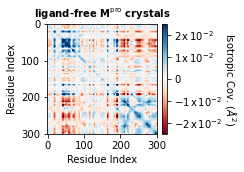

30.741284061745585


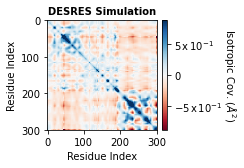

0.4221205985889907


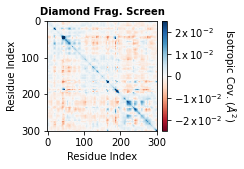

0.05090219896178288


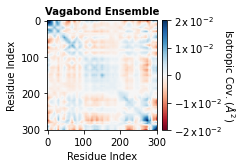

4.9104622057344915


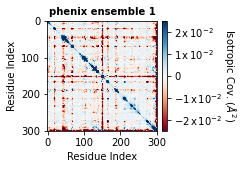

2.8794678655751205


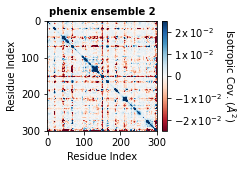

5.0428361506394745


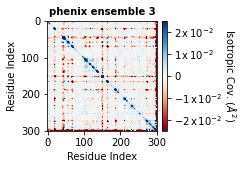

3.5388307522081894


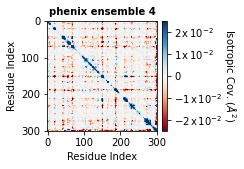

In [27]:
ticks = np.arange(0, crystals.xyz.shape[1], 100)
cmap = 'RdBu'

# title, matrix to plot, filename to save
datasets = [
    (r'ligand-free M$^\mathrm{pro}$ crystals', S_xtal, "cov_xtal_ensemble"),
    ('DESRES Simulation', S_md[:S_xtal.shape[0],:S_xtal.shape[1]], "cov_md"),
    ('Diamond Frag. Screen', S_dmnd, "cov_dmnd_ensemble"),
    ('Vagabond Ensemble', S_vaga, "cov_vagabond_ensemble"),
] + phenix_ensemble_datasets


# how much to zoom colorbar
scales = [
    0.025,
    0.9,
    0.025,
    0.020,
    0.025, 0.025, 0.025, 0.025,
]

for i_d, dataset in enumerate(datasets):

    figsize = (3.5,3.5)

    fig = plt.figure(figsize=figsize)
    ax1 = plt.subplot(111)

    ax1.set_title(dataset[0], 
                  fontweight='bold', fontsize=10)
    

    print(dataset[1].max())
    im = ax1.imshow(
        dataset[1],
        cmap=cmap, 
        vmin=-scales[i_d],
        vmax=scales[i_d],
    )

    ax1.set_xticks(ticks)
    ax1.set_xticklabels([str(int(t)) for t in ticks])
    ax1.set_yticks(ticks)
    ax1.set_yticklabels([str(int(t)) for t in ticks])
    ax1.set_xlabel('Residue Index')
    ax1.set_ylabel('Residue Index')
    
    # ax1.set_xticks([])
    # ax1.set_yticks([])

    cbar = plt.colorbar(im, ax=ax1, fraction=0.046, pad=0.04, format=FuncFormatter(sci_notation_no_sigfigs))
    
    cbar.set_label('Isotropic Cov. ($\AA^2$)', rotation=270, labelpad=15)

    plt.tight_layout()
    plt.savefig(f'./figures/covariance_matrices/{dataset[2]}.pdf')
    plt.show()

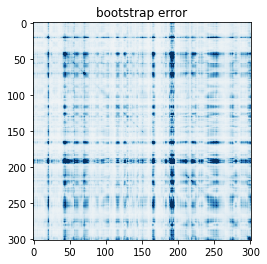

In [19]:
plt.figure()
plt.title('bootstrap error')
plt.imshow(err_S_xtal, cmap=cmap, vmin=-scales[0]/10, vmax=scales[0]/10)
plt.show()

In [20]:
mu_xtal  = np.abs(S_xtal[active_site_residues,:]).mean(0)
std_xtal = np.abs(S_xtal[active_site_residues,:]).std(0)

err_mu_xtal = np.sqrt(np.mean(np.square(err_S_xtal[active_site_residues,:]), axis=0)) # 1-sigma

mu_md  = np.abs(S_md[active_site_residues,:S_xtal.shape[0]]).mean(0)
std_md = np.abs(S_md[active_site_residues,:S_xtal.shape[0]]).std(0)

mu_dmnd  = np.abs(S_dmnd[active_site_residues,:S_xtal.shape[0]]).mean(0)
std_dmnd = np.abs(S_dmnd[active_site_residues,:S_xtal.shape[0]]).std(0)

mu_vaga  = np.abs(S_dmnd[active_site_residues,:S_xtal.shape[0]]).mean(0)
std_vaga = np.abs(S_dmnd[active_site_residues,:S_xtal.shape[0]]).std(0)

# ----------------------------------------------------------------------------

np.savetxt('Ca_covariance_matrix.txt', mu_xtal)
# np.savetxt('saved/ca_corr_md.txt', mu_md)

## View correlation projected on active site

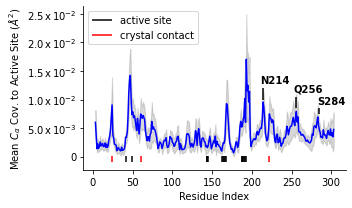

In [21]:
res_idx = np.arange(S_xtal.shape[0]) + 3

plt.figure(figsize=(5,3))

ax1 = plt.subplot(111)

ax1.plot(res_idx, mu_xtal, color='b')

ax1.fill_between(res_idx, mu_xtal - err_mu_xtal * 3, mu_xtal + err_mu_xtal * 3, 
                alpha=0.3, color='grey')

ax1.set_xlabel(r'Residue Index')
ax1.set_ylabel(r'Mean $C_\alpha$ Cov. to Active Site ($\AA^2$)')
#ax1.set_yticks([])
ax1.yaxis.set_major_formatter(FuncFormatter(sci_notation_one_sigfig))

BAR_SIZE = 0.0012
BAR_FLOOR = -0.001

# crystal contacts
cont = ax1.vlines(24, BAR_FLOOR, BAR_FLOOR + BAR_SIZE, color='r')
ax1.vlines(60, BAR_FLOOR, BAR_FLOOR + BAR_SIZE, color='r')
ax1.vlines(222, BAR_FLOOR, BAR_FLOOR + BAR_SIZE, color='r')

# active site residues
for r in active_site_residues:
    act = ax1.vlines(r+3, BAR_FLOOR, BAR_FLOOR + BAR_SIZE)

# interesting
x_shift = -0
y_shift = 0.005
ax1.text(210 + x_shift, mu_xtal[213] + y_shift + 0.001,  'N214', weight='bold')
ax1.text(252 + x_shift, mu_xtal[255] + y_shift - 0.0005, 'Q256', weight='bold')
ax1.text(282 + x_shift, mu_xtal[283] + y_shift,  'S284', weight='bold')

ax1.vlines(214, 0.01, 0.012)
ax1.vlines(256, 0.0085, 0.0105)
ax1.vlines(284, 0.0075, 0.0085)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
    
plt.legend([act, cont], ['active site', 'crystal contact'], loc=2)
    
plt.tight_layout()
plt.savefig('figures/cov_to_active.pdf')
plt.show()

Compare with MD simulation

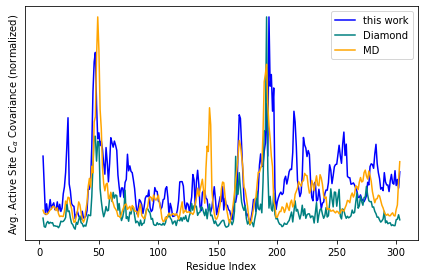

In [22]:
plt.figure(figsize=(6,4))

ax1 = plt.subplot(111)

p1 = ax1.plot(res_idx, mu_xtal / mu_xtal.max(), color='b')
p2 = ax1.plot(res_idx, mu_dmnd / mu_dmnd.max(), color='teal')
p3 = ax1.plot(res_idx, mu_md / mu_md.max(), color='orange')

ax1.set_xlabel('Residue Index')
ax1.set_ylabel(r'Avg. Active Site $C_\alpha$ Covariance (normalized)')
ax1.set_yticks([])

plt.legend(['this work', 'Diamond', 'MD'])
 
plt.savefig('figures/screen_md_diamond_corr.pdf')
plt.tight_layout()
plt.show()

## absolute correlation (ie include off diagonal elements)

In [23]:
S_xtal_abs = abs_cov(crystals.xyz)

mu_xtal_abs  = np.abs(S_xtal_abs[active_site_residues,:]).mean(0)
std_xtal_abs = np.abs(S_xtal_abs[active_site_residues,:]).std(0)

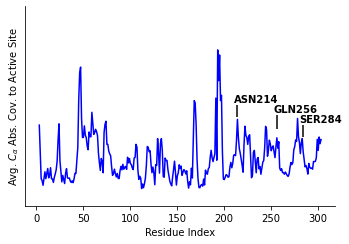

In [24]:
plt.figure(figsize=(5,3.5))

ax1 = plt.subplot(111)

ax1.plot(res_idx, mu_xtal_abs, color='b')

ax1.set_xlabel(r'Residue Index')
ax1.set_ylabel(r'Avg. $C_\alpha$ Abs. Cov. to Active Site')
ax1.set_yticks([])

# interesting
y_offset = 0.0002
ax1.text(210, mu_xtal_abs[213] + y_offset - 0.00001, 'ASN214', weight='bold')
ax1.text(252, mu_xtal_abs[255] + y_offset - 0.00008, 'GLN256', weight='bold')
ax1.text(280, mu_xtal_abs[283] + y_offset - 0.00002, 'SER284', weight='bold')

ax1.set_ylim([-0.00001, 0.0008])

ax1.vlines(214, 0.00035, 0.0004)
ax1.vlines(256, 0.00030, 0.00036)
ax1.vlines(284, 0.00027, 0.00032)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

    
plt.tight_layout()
plt.savefig('figures/cov_to_active_including_off_diagonal.pdf')
plt.show()

## Variance Only (control)

In [25]:
variance_xtal = np.diag(S_xtal)
variance_xtal.shape

(301,)

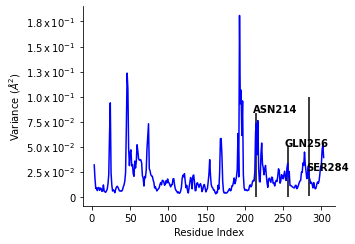

In [26]:
plt.figure(figsize=(5,3.5))

ax1 = plt.subplot(111)

ax1.plot(res_idx, variance_xtal, color='b')

ax1.set_xlabel(r'Residue Index')
ax1.set_ylabel(r'Variance ($\AA^2$)')
ax1.yaxis.set_major_formatter(FuncFormatter(sci_notation_one_sigfig))

# interesting
y_offset = 0.0002
ax1.text(210, variance_xtal[213] * 2, 'ASN214', weight='bold')
ax1.text(252, variance_xtal[255] * 2, 'GLN256', weight='bold')
ax1.text(280, variance_xtal[283] * 2, 'SER284', weight='bold')

#ax1.set_ylim([-0.00001, 0.0008])

ax1.vlines(214, 0, variance_xtal[213] * 2)
ax1.vlines(256, 0, variance_xtal[255] * 2)
ax1.vlines(284, 0.00027, 0.1)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

    
plt.tight_layout()
#plt.savefig('figures/variance.pdf')
plt.show()